# Import everything needed

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter.filedialog import askopenfilenames
from scipy.optimize import curve_fit
import os
import sys
from scipy.interpolate import interp1d
from scipy.io import loadmat
import xarray as xr
#from lmfit import Model, Parameters, minimize
import copy
%matplotlib widget
#Allow more than one notebook output
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"



def load_data(path):
    files =  os.listdir(path)
    if len(files) != 2:
        print("Unexpected number of files. Please, have only the Frog and xFrog in the folder")
        sys.exit()
    data1 = np.loadtxt(os.path.join(path, files[0]))
    data2 = np.loadtxt(os.path.join(path, files[1]))
    if len(data2)>len(data1):
        frog = data2
        xfrog = data1
    else:
        frog = data1
        xfrog = data2
    DataFrame = xr.DataArray(
        np.transpose(frog[1:]),
        coords={"wl": frog[0],"time": xfrog},
        dims =['wl',"time",]
    )
    return DataFrame

def heatmap(DataFrame,Pulse_Length,_show_Length=False):
    plt.figure()
    plt.pcolormesh(DataFrame['time'],DataFrame['wl'], DataFrame.values, cmap='jet', shading='auto')
    plt.xlabel('time (fs)')
    plt.ylabel('Wavelength  (nm)')
    plt.colorbar()
    if _show_Length == True:
        plt.text(0.05, 0.95, f'Pulse Length: {Pulse_Length:.1f} fs', 
        fontsize=12, color='white', transform=plt.gca().transAxes,
        ha='left', va='top', bbox=dict(facecolor='black', alpha=0.5))
    plt.show()


def calculate_fwhm(spectral_data, time_coords):
    spectral_data = np.abs(spectral_data)
    peak_value = np.max(spectral_data)
    half_max = peak_value / 2.0
    indices_above_half = np.where(spectral_data >= half_max)[0]
    # Interpolate to get a more accurate crossing point
    f_left = interp1d(spectral_data[indices_above_half[0]-1:indices_above_half[0]+1], time_coords[indices_above_half[0]-1:indices_above_half[0]+1], kind='linear')
    f_right = interp1d(spectral_data[indices_above_half[-1]:indices_above_half[-1]+2], time_coords[indices_above_half[-1]:indices_above_half[-1]+2], kind='linear')
    left_half_max_time = f_left(half_max)
    right_half_max_time = f_right(half_max)
    
    # Calculate FWHM as the difference between these two time points
    fwhm = right_half_max_time - left_half_max_time

    return fwhm

def gaussian(x, mu, sigma):
  return np.exp(-np.power(x - mu, 2.) / (2 * np.power(sigma, 2.)))

###Speed of light conversion ################
c = 299792458 #m/s
c = c*1000 #mm/s
c = c*10**(-15) #mm/fs


In [66]:
c*400


0.11991698320000001

# Input 

In [86]:
file_path = r'/Users/vard/Documents/FROG/250303_400_800nm/Prism_0p75_final/max265' #Should include only xFrog and Frog 
WLLims = [260,270] #Region where you see the FROG signal
autocorrelation = False 

if autocorrelation == False:
    gate_time = 60 #in fs

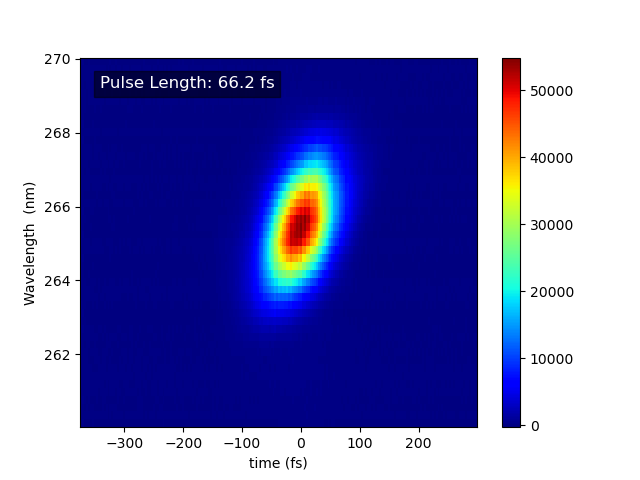

Text(0.5, 1.0, 'Frog 400nm-WL')

<Figure size 640x480 with 0 Axes>

Text(0.05, 0.95, 'Pulse Length: 66.2 fs')

Text(0.05, 0.85, 'FWHM FROG: 89.3 fs')

Text(0.5, 0, 'time (fs)')

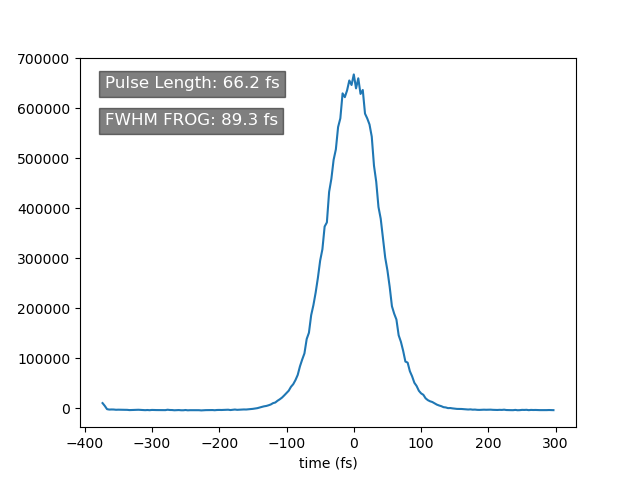

In [87]:
Data = load_data(file_path)
Data = Data.sel(wl= slice(WLLims[0],WLLims[1]))
x0 = Data['time'][Data.sum(dim='wl').argmax()].values #Position of where the Frog is centered
Data['time'] = ((Data['time'].values - x0)/c)*2 #Multiply by 2 as moving the stage changes the distance two time (in and out)
FWHM = calculate_fwhm(Data.sum(dim='wl').values, Data['time'])
if autocorrelation == True:
    Pulse_length = FWHM/np.sqrt(2)
else:
    Pulse_length = np.sqrt(FWHM**2-gate_time**2)
heatmap(Data,Pulse_length,_show_Length=True)
plt.title("Frog 400nm-WL")
plt.figure()
Data.sum(dim='wl').plot()
# Add the line of text for Pulse length
plt.text(0.05, 0.95, f'Pulse Length: {Pulse_length:.1f} fs',
        fontsize=12, color='white', transform=plt.gca().transAxes,
        ha='left', va='top', bbox=dict(facecolor='black', alpha=0.5))

# Add the second line of text for FWHM
plt.text(0.05, 0.85, f'FWHM FROG: {FWHM:.1f} fs',
        fontsize=12, color='white', transform=plt.gca().transAxes,
        ha='left', va='top', bbox=dict(facecolor='black', alpha=0.5))

plt.xlabel('time (fs)')
plt.show()


# Sum Frog Spectrum

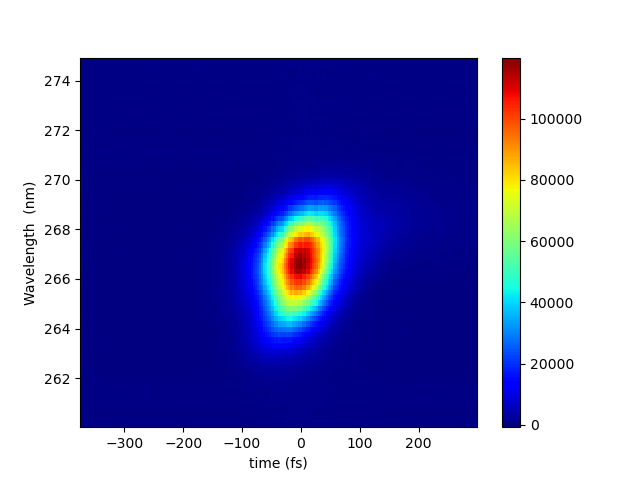

Text(0.5, 1.0, 'Summed FROG  800-400nm at sample position')

In [78]:
# Define the parent folder where the FROG subfolders are located
parent_folder = r'/Users/vard/Documents/FROG/250303_400_800nm/Prism_0p75_final'  # Change to your parent folder path
WLLims = [260,275]  # Region where you see the FROG signal
pulse_length = 0

# Initialize a variable to hold the sum of all the FROG spectrums
total_frog_data = None

# Iterate over the subfolders in the parent folder
for subfolder in os.listdir(parent_folder):
    subfolder_path = os.path.join(parent_folder, subfolder)
    if os.path.isdir(subfolder_path):
        # Load data for each FROG file in the subfolder
        data = load_data(subfolder_path)
        data = data.sel(wl=slice(WLLims[0], WLLims[1]))  # Slice the data for the desired wavelength range
        if total_frog_data is None:
            total_frog_data = data
        else:
            # Check if coordinates match
            if np.array_equal(data['wl'].values, total_frog_data['wl'].values) and \
                np.array_equal(data['time'].values, total_frog_data['time'].values):
                # Coordinates match, no need to interpolate
                total_frog_data += data
            else:
                # Interpolate data to match the coordinates of total_frog_data
                data = data.interp_like(total_frog_data, method="linear")
                total_frog_data += data
# Now calculate the pulse length and plot the sum of the spectrums
x0 = total_frog_data['time'][total_frog_data.sum(dim='wl').argmax()].values  # Position of where the Frog is centered
total_frog_data['time'] = ((total_frog_data['time'].values - x0) / c) * 2  # Multiply by 2 as moving the stage changes the distance two times (in and out)



# Plot the heatmap of the summed FROG data
heatmap(total_frog_data, pulse_length , _show_Length=False)
plt.title("Summed FROG  800-400nm at sample position")


# Get duration from the summed spectrum

<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'time (fs)')

Text(0.05, 0.95, 'Pulse Length: 60.3 fs')

Text(0.05, 0.85, 'FWHM FROG: 85.1 fs')

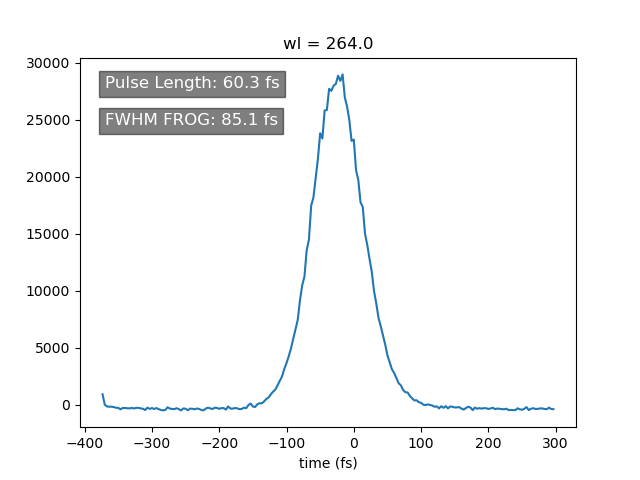

In [92]:
Wavelength = 264 #wavelength where to look at for the pulse duration
autocorrelation = False 
gate_time = 60 #in fs, if autocorrelation false
plt.figure()

# Plot the sum of the spectrums and calculate FWHM
total_frog_data.sel(wl = Wavelength, method='Nearest').plot()
FWHM = calculate_fwhm(total_frog_data.sel(wl = Wavelength, method='Nearest'), total_frog_data['time'])
if autocorrelation == True:
        Pulse_length = FWHM/np.sqrt(2)
else:
        Pulse_length = np.sqrt(FWHM**2-gate_time**2)
plt.xlabel('time (fs)')
# Add the line of text for Pulse length
plt.text(0.05, 0.95, f'Pulse Length: {Pulse_length:.1f} fs',
        fontsize=12, color='white', transform=plt.gca().transAxes,
        ha='left', va='top', bbox=dict(facecolor='black', alpha=0.5))

# Add the second line of text for FWHM
plt.text(0.05, 0.85, f'FWHM FROG: {FWHM:.1f} fs',
        fontsize=12, color='white', transform=plt.gca().transAxes,
        ha='left', va='top', bbox=dict(facecolor='black', alpha=0.5))

plt.show()